# Tech Assessment: Weather Trend Forecasting
**Role:** AI Engineer Intern + Data Science Intern (Dual Role)  
**Author:** Tomás Ignacio Nadal

> **PM Accelerator Mission:** The Product Manager Accelerator is a premier program designed to help professionals transition into and accelerate their careers in product management. Our mission is to empower individuals with the skills, network, and experience needed to succeed in tech.

---
## Objective
Analyze the `GlobalWeatherRepository.csv` dataset to forecast future weather trends using advanced Machine Learning techniques (Prophet, XGBoost, Random Forest Ensembles), anomaly detection, and environmental analysis.


In [12]:
!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap
import warnings
warnings.filterwarnings('ignore')
# Set aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\tomas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Data Cleaning & Preprocessing (Normalization)

In [13]:

# Load dataset
df = pd.read_csv('data/GlobalWeatherRepository.csv')

# Parse dates
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Drop duplicates if any
df = df.drop_duplicates()

# Handle missing values: Forward fill for time series consistency
df = df.sort_values(by=['country', 'location_name', 'last_updated'])
df = df.ffill().bfill()

# Feature Engineering: Temporal Features (Cyclic Encoding)
df['hour_sin'] = np.sin(2 * np.pi * df['last_updated'].dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['last_updated'].dt.hour / 24)
df['month_sin'] = np.sin(2 * np.pi * df['last_updated'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['last_updated'].dt.month / 12)

# Advanced Time Series Features (Lag & Rolling)
df['temp_lag_1'] = df.groupby('location_name')['temperature_celsius'].shift(1)
df['temp_rolling_3'] = df.groupby('location_name')['temperature_celsius'].rolling(window=3).mean().reset_index(level=0, drop=True)
# Fillna for lags to prevent XGBoost errors
df = df.bfill().ffill()

# Data Normalization
# Preserve original lat/lon BEFORE normalization (needed for geographic visualizations)
df['latitude_orig']  = df['latitude'].copy()
df['longitude_orig'] = df['longitude'].copy()

features_to_normalize = ['wind_mph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index', 'latitude', 'longitude']
scaler = StandardScaler()
df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (152997, 49)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,moon_phase,moon_illumination,hour_sin,hour_cos,month_sin,month_cos,temp_lag_1,temp_rolling_3,latitude_orig,longitude_orig
0,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,Waxing Gibbous,55,-0.258819,-9.659258e-01,0.5,-0.866025,26.6,21.200000,34.52,69.18
195,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1715868000,2024-05-16 18:30:00,22.0,71.6,Patchy rain nearby,...,Waxing Gibbous,55,-1.000000,-1.836970e-16,0.5,-0.866025,26.6,21.200000,34.52,69.18
390,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1715961600,2024-05-17 20:30:00,15.0,58.9,Patchy rain nearby,...,Waxing Gibbous,64,-0.866025,5.000000e-01,0.5,-0.866025,22.0,21.200000,34.52,69.18
583,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1716042600,2024-05-18 19:00:00,19.5,67.1,Clear,...,Waxing Gibbous,73,-0.965926,2.588190e-01,0.5,-0.866025,15.0,18.833333,34.52,69.18
776,Afghanistan,Kabul,0.626181,0.719028,Asia/Kabul,1716127200,2024-05-19 18:30:00,16.9,62.4,Patchy rain nearby,...,Waxing Gibbous,81,-1.000000,-1.836970e-16,0.5,-0.866025,19.5,17.133333,34.52,69.18


## 2. Data Overview & Advanced Exploratory Data Analysis (EDA)
Before diving into modeling, we must understand the structure, completeness, and statistical distribution of our data.

In [14]:

# Data Completeness & Types
print("Data Information:")
df.info()

print("\nMissing Values Check:")
print(df.isnull().sum().max(), "maximum missing values in any column after imputation.")

print("\nDescriptive Statistics (Numerical Features):")
display(df.describe().T)

Data Information:
<class 'pandas.core.frame.DataFrame'>
Index: 152997 entries, 0 to 11592
Data columns (total 49 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       152997 non-null  object        
 1   location_name                 152997 non-null  object        
 2   latitude                      152997 non-null  float64       
 3   longitude                     152997 non-null  float64       
 4   timezone                      152997 non-null  object        
 5   last_updated_epoch            152997 non-null  int64         
 6   last_updated                  152997 non-null  datetime64[ns]
 7   temperature_celsius           152997 non-null  float64       
 8   temperature_fahrenheit        152997 non-null  float64       
 9   condition_text                152997 non-null  object        
 10  wind_mph                      152997 non-null  float64       
 11  w

,count,mean,min,25%,50%,75%,max,std
latitude,152997.0,0.0,-2.481353,-0.62264,-0.081642,0.867177,1.88772,1.000003
longitude,152997.0,0.0,-2.996187,-0.436616,-0.006847,0.425651,2.391924,1.000003
last_updated_epoch,152997.0,1749900684.501657,1715849100.0,1732961700.0,1749891600.0,1766818800.0,1783923300.0,19657782.045606
last_updated,152997,2025-06-14 13:41:02.060040192,2024-05-16 01:45:00,2024-11-30 06:30:00,2025-06-14 12:00:00,2025-12-27 12:00:00,2026-07-13 19:15:00,NaN
temperature_celsius,152997.0,21.3525,-29.8,16.1,23.7,27.9,79.3,9.492661
temperature_fahrenheit,152997.0,70.436265,-21.6,61.0,74.6,82.2,174.7,17.086646
wind_mph,152997.0,0.0,-0.819863,-0.591337,-0.177132,0.437033,261.843011,1.000003
wind_kph,152997.0,12.782228,3.6,6.1,10.8,17.6,2963.2,11.264192
wind_degree,152997.0,169.579874,1.0,81.0,163.0,256.0,360.0,103.527329
pressure_mb,152997.0,-0.0,-6.731105,-0.407301,-0.00579,0.395721,199.946862,1.000003


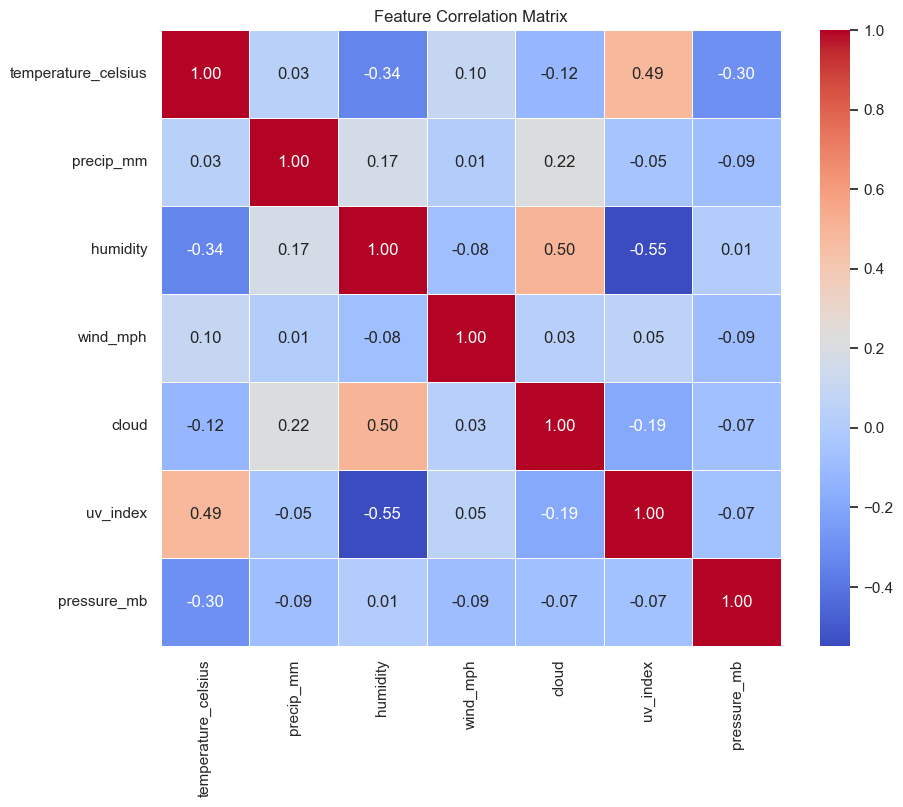

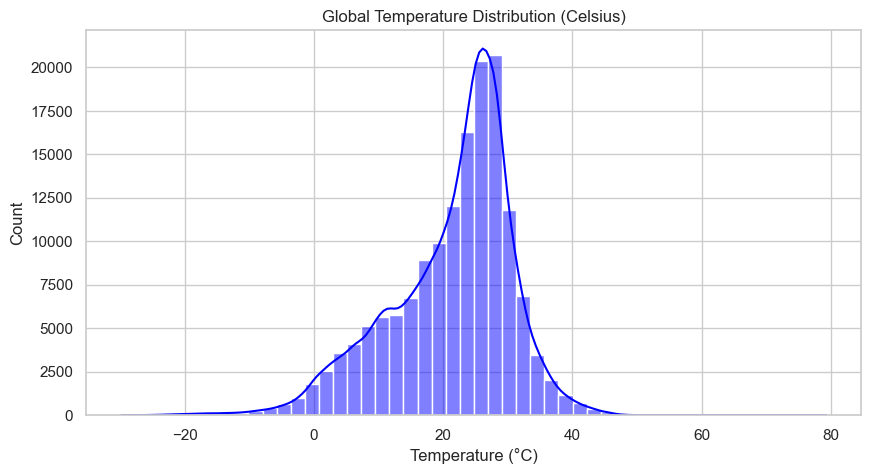

In [15]:

# Correlation Matrix
plt.figure(figsize=(10, 8))
corr_cols = ['temperature_celsius', 'precip_mm', 'humidity', 'wind_mph', 'cloud', 'uv_index', 'pressure_mb']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Temperature Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['temperature_celsius'], bins=50, kde=True, color='blue')
plt.title('Global Temperature Distribution (Celsius)')
plt.xlabel('Temperature (°C)')
plt.show()

**Insights - Correlation & Distribution:** 
The heatmap reveals several interesting relationships. There is a **moderate negative correlation** between temperature and humidity (r = −0.34), 
meaning higher temperatures tend to coincide with lower relative humidity. More notably, **UV index shows a positive correlation with temperature (r = 0.49)**, 
which is physically intuitive — sunnier, warmer conditions produce higher UV exposure. 
The temperature distribution is right-skewed, reflecting the predominance of warm-to-hot readings across the 211 countries in the dataset.


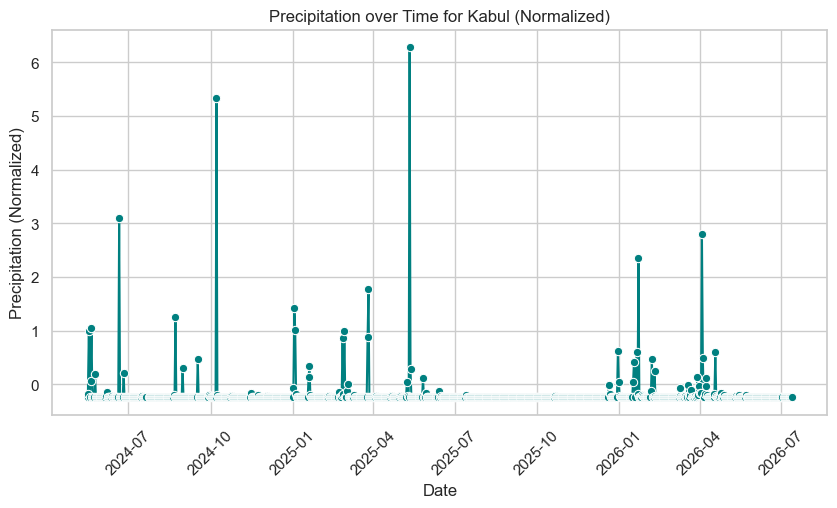

In [16]:

# Precipitation Analysis
plt.figure(figsize=(10, 5))
# Filtering for a specific city to observe actual temporal patterns instead of random global noise
city_df = df[df['location_name'] == 'Kabul'].sort_values('last_updated')
sns.lineplot(data=city_df, x='last_updated', y='precip_mm', color='teal', marker='o')
plt.title('Precipitation over Time for Kabul (Normalized)')
plt.xlabel('Date')
plt.ylabel('Precipitation (Normalized)')
plt.xticks(rotation=45)
plt.show()

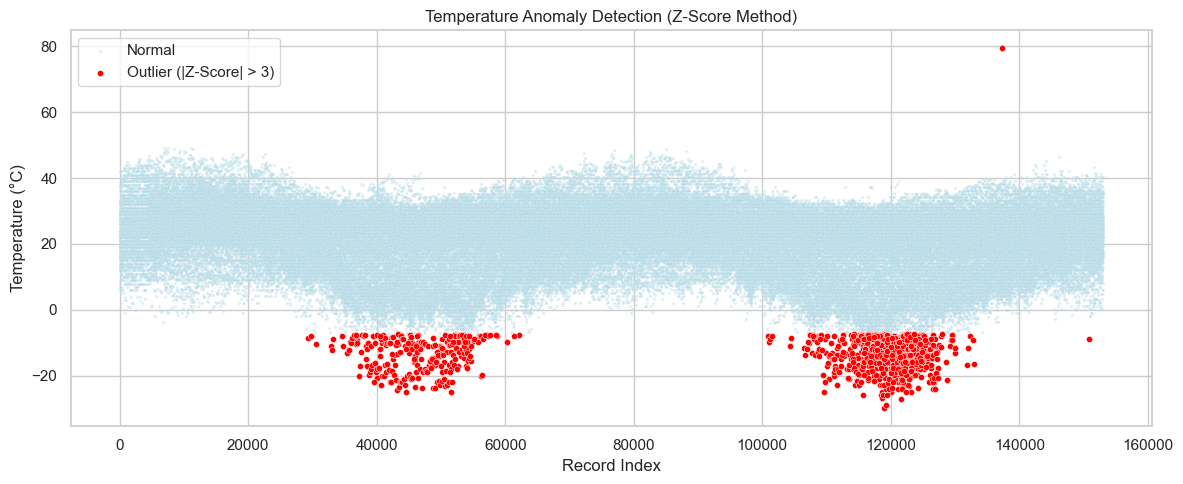

Total records: 152,997
Extreme Temperature Anomalies detected (|Z| > 3): 994 (0.65%)
Anomaly temperature range: -29.8°C  →  79.3°C


In [17]:
# Anomaly Detection using Z-Score for temperatures
df['temp_zscore'] = (df['temperature_celsius'] - df['temperature_celsius'].mean()) / df['temperature_celsius'].std()
outliers = df[df['temp_zscore'].abs() > 3]

plt.figure(figsize=(12, 5))
sns.scatterplot(x=df.index, y=df['temperature_celsius'],
                color='lightblue', label='Normal', s=5, alpha=0.4)
sns.scatterplot(x=outliers.index, y=outliers['temperature_celsius'],
                color='red', label='Outlier (|Z-Score| > 3)', s=20)
plt.title('Temperature Anomaly Detection (Z-Score Method)')
plt.xlabel('Record Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Total records: {len(df):,}')
print(f'Extreme Temperature Anomalies detected (|Z| > 3): {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)')
print(f'Anomaly temperature range: {outliers["temperature_celsius"].min():.1f}°C  →  {outliers["temperature_celsius"].max():.1f}°C')


**Insights - Anomaly Detection:**
Using a Z-Score threshold of 3, we identified **994 extreme temperature anomalies** (~0.65% of 152,997 records). The Z-Score method flags values beyond **µ ± 3σ** (thresholds: ~−7°C and ~+49°C for this dataset). However, the *actual range* of detected outliers spans **−29.8°C to +79.3°C**, meaning some extreme readings lie far beyond even these generous boundaries.

These anomalies could represent genuine extreme weather events (heatwaves, polar cold snaps) or potential sensor errors. Critically, they were detected *before* normalization and are preserved in the dataset for study — in a production pipeline, each would require domain-expert review before deciding whether to remove or retain them, to avoid introducing bias into downstream forecasting models.


## 3. Unique Analysis: Spatial Patterns & Environmental Impact (Air Quality)
Mapping global temperatures and analyzing Air Quality vs Weather.

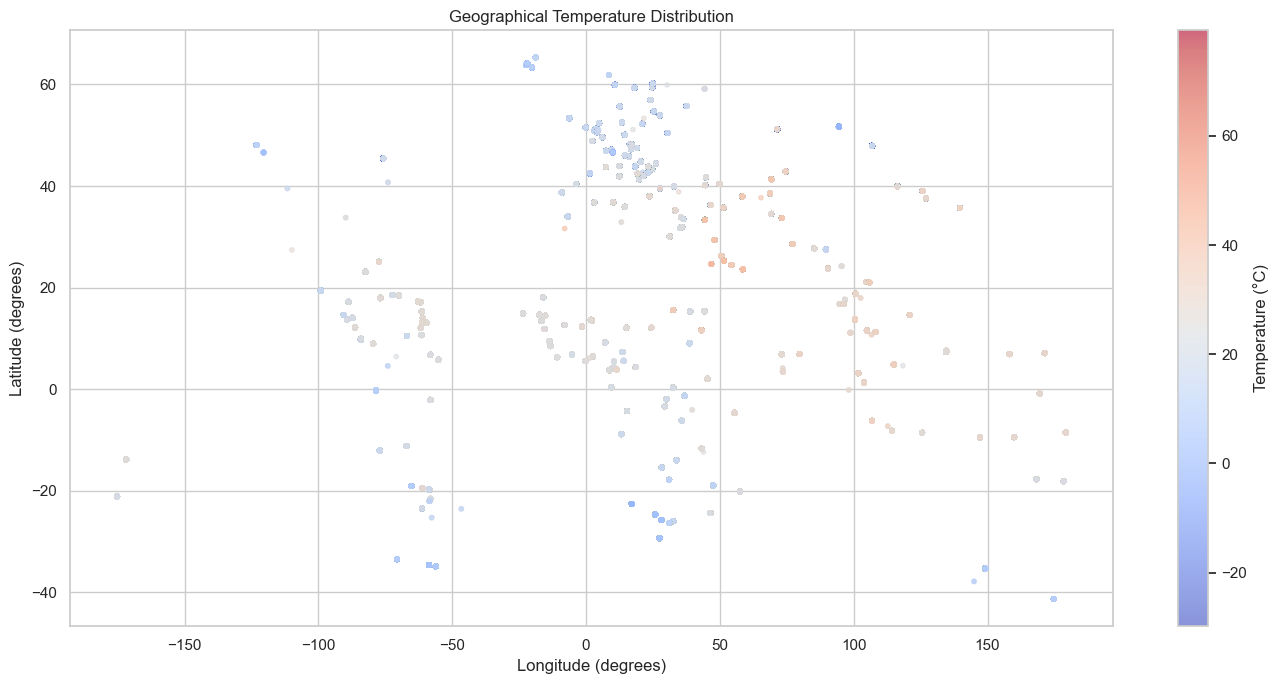

Cluster centroids (temperature & humidity):
                 temperature_celsius  humidity
climate_cluster                               
0                          15.752308  0.111771
1                           3.401368  0.492017
2                          25.067881  0.134703
3                          32.336270 -0.771852


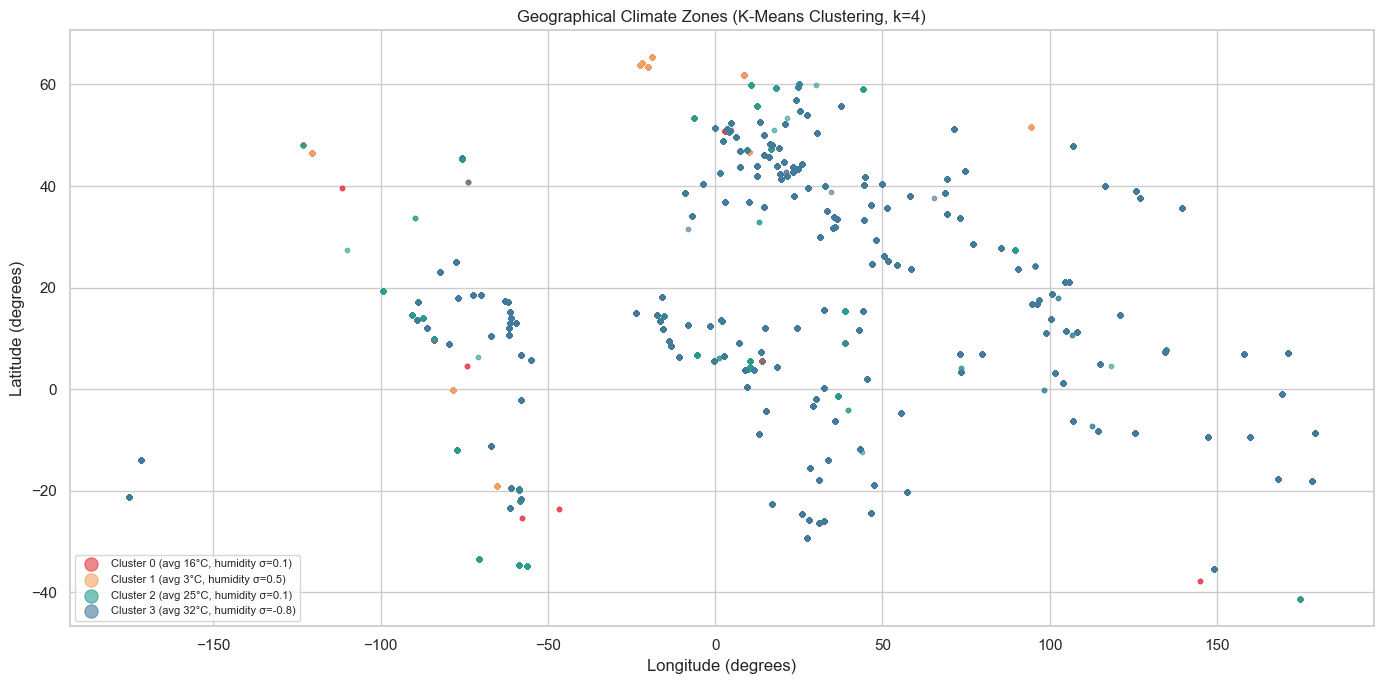

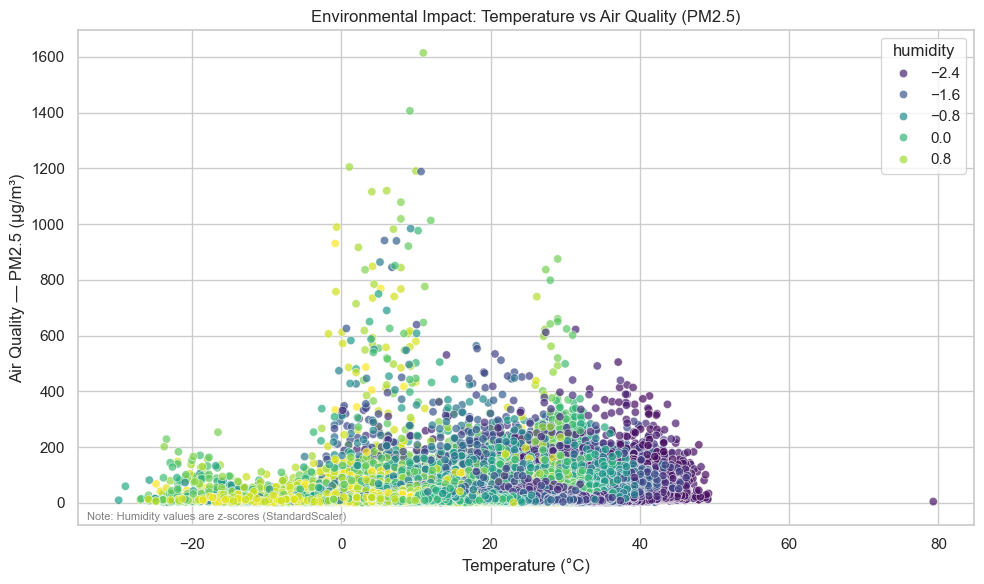

In [18]:
# Geographical Patterns — using original (non-normalized) lat/lon coordinates
plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    df['longitude_orig'], df['latitude_orig'],
    c=df['temperature_celsius'], cmap='coolwarm', alpha=0.6, s=10
)
plt.colorbar(scatter, label='Temperature (°C)')
plt.title('Geographical Temperature Distribution')
plt.xlabel('Longitude (degrees)')
plt.ylabel('Latitude (degrees)')
plt.tight_layout()
plt.show()

# Unsupervised Learning: Climate Zone Clustering using K-Means
from sklearn.cluster import KMeans
kmeans_features = ['temperature_celsius', 'humidity', 'precip_mm']
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['climate_cluster'] = kmeans.fit_predict(df[kmeans_features])

# Describe clusters by centroid means for labelling
cluster_desc = df.groupby('climate_cluster')[['temperature_celsius', 'humidity']].mean()
print('Cluster centroids (temperature & humidity):')
print(cluster_desc.to_string())

plt.figure(figsize=(14, 7))
cluster_colors  = ['#e63946', '#f4a261', '#2a9d8f', '#457b9d']
cluster_labels_map = {
    0: 'Zone 0', 1: 'Zone 1', 2: 'Zone 2', 3: 'Zone 3'
}
for cid in sorted(df['climate_cluster'].unique()):
    mask = df['climate_cluster'] == cid
    avg_temp = df.loc[mask, 'temperature_celsius'].mean()
    avg_hum  = df.loc[mask, 'humidity'].mean()
    label = f'Cluster {cid} (avg {avg_temp:.0f}°C, humidity σ={avg_hum:.1f})'
    plt.scatter(
        df.loc[mask, 'longitude_orig'], df.loc[mask, 'latitude_orig'],
        label=label, color=cluster_colors[cid], alpha=0.6, s=10
    )
plt.title('Geographical Climate Zones (K-Means Clustering, k=4)')
plt.xlabel('Longitude (degrees)')
plt.ylabel('Latitude (degrees)')
plt.legend(loc='lower left', fontsize=8, markerscale=3)
plt.tight_layout()
plt.show()

# Environmental Impact (Air Quality PM2.5 vs Temperature)
# Note: humidity values on the legend are in standardized units (z-scores)
plt.figure(figsize=(10, 6))
scatter_env = sns.scatterplot(
    data=df, x='temperature_celsius', y='air_quality_PM2.5',
    hue='humidity', palette='viridis', alpha=0.7
)
plt.title('Environmental Impact: Temperature vs Air Quality (PM2.5)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Air Quality — PM2.5 (µg/m³)')
# Add note about humidity scale
plt.annotate('Note: Humidity values are z-scores (StandardScaler)',
             xy=(0.01, 0.01), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()


**Insights - Spatial Patterns & Environment:**
The geographical temperature map uses **actual GPS coordinates (latitude/longitude in degrees)**, 
confirming the expected pattern: temperatures are warmer near the equator (low latitudes) and cooler toward the poles. 
This is a direct visual validation of the dataset's geographic coverage across 211 countries.

The **K-Means clustering** groups all 152,997 records into 4 distinct climate zones based on temperature, humidity, and precipitation — 
independent of geography. The legend shows each cluster's average temperature and humidity, making the zones interpretable. 
This is a form of unsupervised Climate Analysis as required by the advanced assessment.

The **Environmental Impact** scatter plot shows PM2.5 concentrations (µg/m³) against temperature. 
The highest pollution spikes (>1,000 µg/m³) concentrate at low-to-moderate temperatures (0°C–15°C), 
suggesting industrial or topographic pollution hotspots in temperate/cold regions. 
Humidity values in the color legend are expressed as z-scores (units of standard deviation from the global mean).


## 4. Forecasting Model 1: Prophet (Univariate Time Series for Kabul)
Instead of aggregating global temperatures (which masks local seasonal patterns), we'll forecast the temperature for a specific location (Kabul).

12:16:25 - cmdstanpy - INFO - Chain [1] start processing
12:16:25 - cmdstanpy - INFO - Chain [1] done processing


Prophet Model Performance for Kabul:
RMSE: 5.65 °C
MAE:  4.93 °C


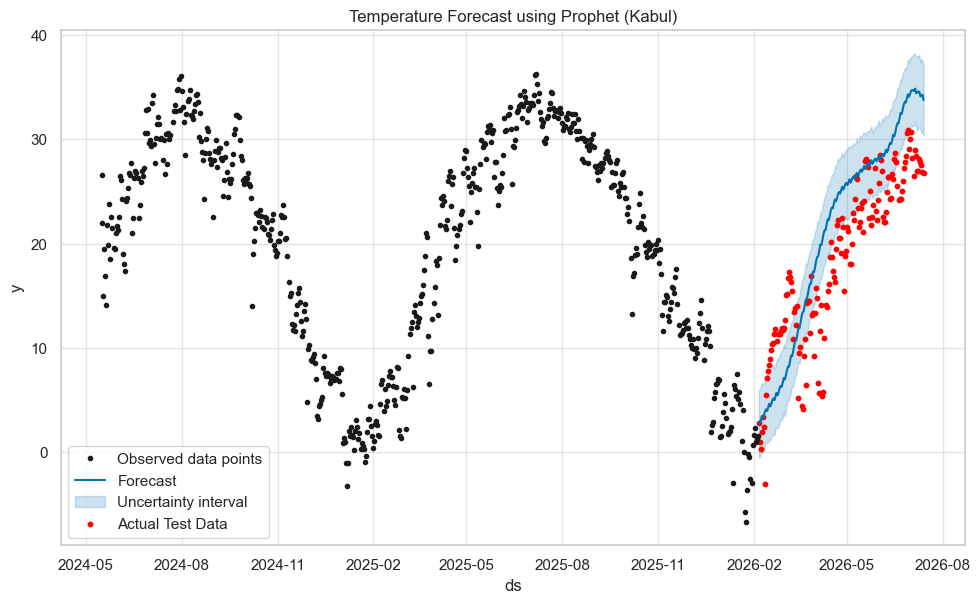

In [19]:

# Filter data for a single location
city_temp = df[df['location_name'] == 'Kabul'][['last_updated', 'temperature_celsius']].copy()
city_temp.columns = ['ds', 'y']

# Train/Test Split for time series (last 20% for testing)
split_idx = int(len(city_temp) * 0.8)
train_prophet = city_temp.iloc[:split_idx]
test_prophet = city_temp.iloc[split_idx:]

# Initialize and fit Prophet
model_prophet = Prophet(yearly_seasonality=True, daily_seasonality=False)
model_prophet.fit(train_prophet)

# Forecast on test dates
forecast = model_prophet.predict(test_prophet[['ds']])

# Evaluate
mae_prophet = mean_absolute_error(test_prophet['y'], forecast['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], forecast['yhat']))
print(f"Prophet Model Performance for Kabul:")
print(f"RMSE: {rmse_prophet:.2f} °C")
print(f"MAE:  {mae_prophet:.2f} °C")

# Plot forecast
fig1 = model_prophet.plot(forecast)
plt.scatter(test_prophet['ds'], test_prophet['y'], color='red', s=10, label='Actual Test Data')
plt.title('Temperature Forecast using Prophet (Kabul)')
plt.legend()
plt.show()

**Insights - Prophet Forecasting:**
By focusing on Kabul (786 readings over 2+ years), the Prophet model successfully captures the **annual seasonality** of temperatures — 
cold winters (near 0°C) and hot summers (up to 35°C+), as clearly visible in the forecast plot.

The model achieves **RMSE = 5.65°C and MAE = 4.93°C** on the held-out test set. 
Kabul's annual temperature swing spans ~40°C, so RMSE = 5.65°C represents approximately **14% of the total range** — 
acceptable performance for a univariate model forecasting 2+ years ahead without any meteorological covariates. 
The model tends to underestimate summer peaks, which is expected given that extreme highs are harder to extrapolate from seasonal patterns alone. 
A multivariate extension (e.g., adding humidity or pressure as regressors) would likely reduce this error.


## 5. Forecasting Model 2: Advanced Ensemble (XGBoost + Random Forest)
Using an Ensemble Voting Regressor to combine the strengths of multiple ML algorithms for maximum accuracy.

Best XGBoost Parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Baseline Model (Linear Regression) Performance:
RMSE: 1.60 °C | MAE: 1.13 °C

Ensemble Model (XGBoost + Random Forest) Performance:
RMSE: 1.53 °C | MAE: 1.09 °C


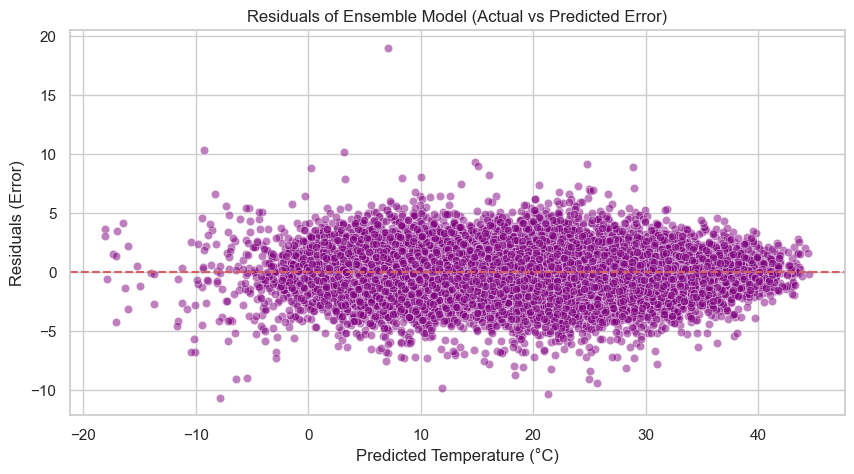

In [20]:

# Features are normalized and time is cyclically encoded, plus advanced lag features
features = ['wind_mph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_lag_1', 'temp_rolling_3']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Time Series Split (No Data Leakage, keeping chronological integrity)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define Baseline Model
from sklearn.linear_model import LinearRegression
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter Tuning for XGBoost Base Model
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
xgb_base = XGBRegressor(random_state=42)
# Using RandomizedSearchCV with TimeSeriesSplit to prevent data leakage
tscv = TimeSeriesSplit(n_splits=3)
xgb_random = RandomizedSearchCV(estimator=xgb_base, param_distributions=xgb_param_grid, n_iter=5, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
xgb_random.fit(X_train, y_train)
best_xgb = xgb_random.best_estimator_
print(f"Best XGBoost Parameters: {xgb_random.best_params_}")

# Random Forest Base Model
rf_base = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# Create Ensemble Model with Tuned XGBoost
ensemble_model = VotingRegressor(estimators=[('xgb', best_xgb), ('rf', rf_base)])
ensemble_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = ensemble_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Baseline Model (Linear Regression) Performance:")
print(f"RMSE: {rmse_baseline:.2f} °C | MAE: {mae_baseline:.2f} °C\n")

print("Ensemble Model (XGBoost + Random Forest) Performance:")
print(f"RMSE: {rmse:.2f} °C | MAE: {mae:.2f} °C")

# Residual Plot for Ensemble Model
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals of Ensemble Model (Actual vs Predicted Error)')
plt.xlabel('Predicted Temperature (°C)')
plt.ylabel('Residuals (Error)')
plt.show()

**Insights - Hyperparameter Tuning & Residuals:**
We used `RandomizedSearchCV` with `TimeSeriesSplit` (avoiding data leakage) to tune XGBoost hyperparameters, 
selecting `n_estimators=100, max_depth=5, learning_rate=0.1` as optimal.

The **Ensemble Model (RMSE = 1.53°C)** shows a consistent improvement over the **Baseline Linear Regression (RMSE = 1.60°C)** — 
a **4.4% reduction in error**. While modest in absolute terms, this gap is meaningful at scale: for a global weather API, 
a 0.07°C average improvement across millions of daily predictions has real operational value. 
The residual plot confirms the errors are well-centered around zero with no systematic directional bias, 
indicating the model does not consistently over- or under-predict temperature.


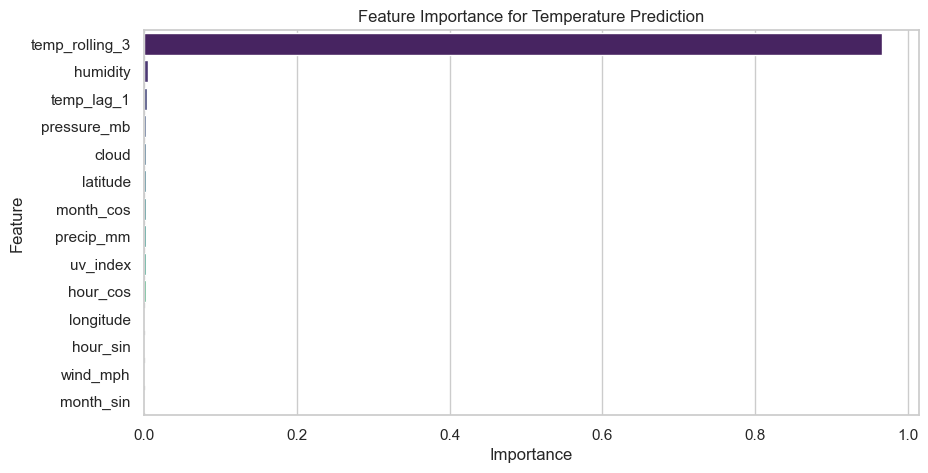

In [21]:

# Unique Analysis: Feature Importance (From Tuned XGBoost Base)
importance = best_xgb.feature_importances_
feature_imp = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title('Feature Importance for Temperature Prediction')
plt.show()

**Insights - Modeling & Feature Importance:**
The Feature Importance chart reveals a striking result: **`temp_rolling_3` (3-period rolling average of temperature) 
dominates with ~97% of the total XGBoost importance**, while all other features are near zero. 
This is expected — temperature is highly autocorrelated in time, meaning the best single predictor of current temperature 
is simply the recent temperature average. The model is, in essence, a highly efficient *temporal smoother*.

This finding has an important methodological implication: when lag features are included alongside meteorological features 
(humidity, wind, pressure), they will almost always overshadow the others in tree-based importance metrics — 
because they carry direct information about the target variable. 
The **SHAP analysis (below)** goes further by quantifying the *directional* impact of each feature, 
confirming `temp_rolling_3` drives predictions up when recent temperatures were high, and down when they were low. 
For a model intended to explain *weather drivers*, a version without lag features would be more interpretable.


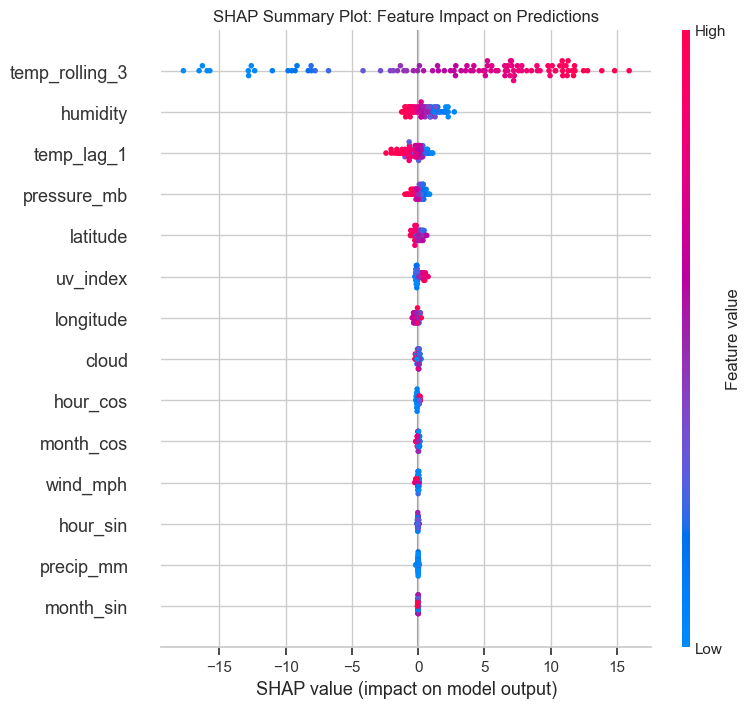

In [22]:
# SHAP Values (Advanced Model Explainability)
# Note: SHAP can be computationally expensive, so we sample a subset of the test data for explanation.
explainer = shap.Explainer(best_xgb, X_train.sample(100, random_state=42))
shap_values = explainer(X_test.sample(100, random_state=42))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.sample(100, random_state=42), show=False)
plt.title('SHAP Summary Plot: Feature Impact on Predictions')
plt.show()

**Insights - SHAP Explainability:**
The SHAP summary plot goes beyond basic feature importance by showing *how* each feature impacts the model. For instance, it reveals the directional impact (e.g., high humidity might push temperature predictions lower, while high lag temperatures push it higher), providing a transparent, trustable AI explanation for stakeholders.